In [1]:
# Basic python
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Logging
import logging
logging.getLogger().setLevel(logging.INFO)

# Data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Project modules
sys.path.append(os.path.abspath("src"))
from data_ravers_utils.file_handler import *


# Load test dataframe and saved model pipeline

In [2]:
filename='handcrafted_features_logistic_regression_model'
handcrafted_model = read_model_pickle(filename)

print(handcrafted_model)

# verify that the model is trained on 25 handcrafted features
clf = handcrafted_model.named_steps["clf"]
print("n_features_in_ =", clf.n_features_in_)

Pipeline(steps=[('features', TextFeatureExtractor()),
                ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))])
n_features_in_ = 25


In [3]:
df_filename = 'df_testing_data_v0'

data = read_df_pickle(df_filename)
df_test = data.copy()
df_test.head(5)

,label,text
0,1,"Cuando conocí a Janice en 2013 , una familia n..."
1,0,Hwang habló en Sur de este año por Southwest M...
2,1,Usted podría pensar Katy Perry y Robert Pattin...
3,1,Cualquiera que haya volado los cielos del crea...
4,1,"Bueno , este cantante tendrá un LARGO tiempo p..."


In [4]:
# TODO: export to utils/eda/auto_cleanup

def basic_cleanup(s: str) -> str:
    if not isinstance(s, str):
        return ""
    # remove control characters 0x00–0x1f
    return "".join(ch for ch in s if ord(ch) >= 32)

df_test["text_clean"] = df_test["text"].apply(basic_cleanup)

In [5]:
X_test = df_test["text_clean"]

# predicted labels 0/1
y_pred = handcrafted_model.predict(X_test)

# optional: class probabilities (for analysis / thresholding)
if hasattr(handcrafted_model.named_steps["clf"], "predict_proba"):
    y_proba = handcrafted_model.predict_proba(X_test)[:, 1]  # prob of class 1 (human)
else:
    y_proba = None

In [6]:
# ajoin the predicted label
df_test["label_pred"] = y_pred

# bonus: probabilities
if y_proba is not None:
    df_test["prob_human"] = y_proba
    df_test["prob_machine"] = 1 - y_proba

df_test.head()

,label,text,text_clean,label_pred,prob_human,prob_machine
0,1,"Cuando conocí a Janice en 2013 , una familia n...","Cuando conocí a Janice en 2013 , una familia n...",1,0.523312,0.476688
1,0,Hwang habló en Sur de este año por Southwest M...,Hwang habló en Sur de este año por Southwest M...,0,0.476916,0.523084
2,1,Usted podría pensar Katy Perry y Robert Pattin...,Usted podría pensar Katy Perry y Robert Pattin...,1,0.621054,0.378946
3,1,Cualquiera que haya volado los cielos del crea...,Cualquiera que haya volado los cielos del crea...,1,0.559670,0.440330
4,1,"Bueno , este cantante tendrá un LARGO tiempo p...","Bueno , este cantante tendrá un LARGO tiempo p...",1,0.533973,0.466027


In [7]:
df_submit = df_test.copy()

df_submit = df_submit[["label", "label_pred", "text"]]

df_submit.head()

,label,label_pred,text
0,1,1,"Cuando conocí a Janice en 2013 , una familia n..."
1,0,0,Hwang habló en Sur de este año por Southwest M...
2,1,1,Usted podría pensar Katy Perry y Robert Pattin...
3,1,1,Cualquiera que haya volado los cielos del crea...
4,1,1,"Bueno , este cantante tendrá un LARGO tiempo p..."


In [8]:
save_df_pickle(df_submit, "df_testing_with_predictions_v1")

INFO:root:Backup file is created: /Users/bubblegum_doubledrops/Library/Mobile Documents/com~apple~CloudDocs/0prio - Important heavy backups/IronHack/mini_projects/project-3-nlp/data/df_testing_with_predictions_v1.pkl


In [9]:
save_df_as_csv(df_test, "testing_data_with_predictions")

INFO:root:CSV file created: /Users/bubblegum_doubledrops/Library/Mobile Documents/com~apple~CloudDocs/0prio - Important heavy backups/IronHack/mini_projects/project-3-nlp/data/testing_data_with_predictions.csv


In [10]:
# correct predictions
(df_test["label_pred"] == df_test["label"]).sum()

np.int64(7992)

In [11]:
(df_test["label_pred"] != df_test["label"]).sum()

np.int64(6932)

In [12]:
accuracy = (df_test["label_pred"] == df_test["label"]).mean()
print("Accuracy on test data:", accuracy)

Accuracy on test data: 0.5355132672205843


<Figure size 600x600 with 0 Axes>

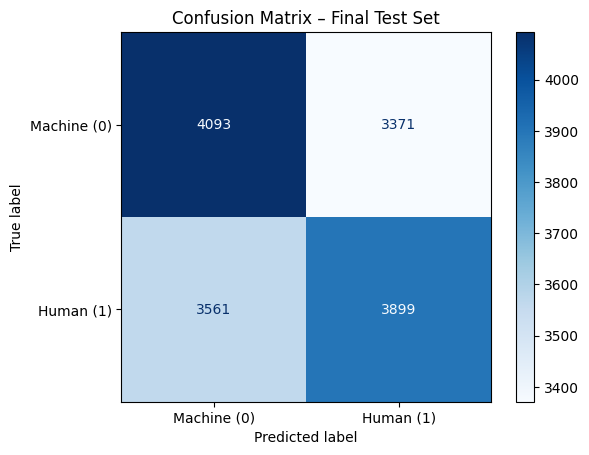

In [13]:
y_true = df_test["label"]
y_pred = df_test["label_pred"]

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Machine (0)", "Human (1)"]
)
plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix – Final Test Set")
plt.show()

### Confusion Matrix — Interpretation
- The model performs *almost symmetrically* on both classes.
- **Machine (0)**: Correct 4093, incorrect 3371 → slightly better than random.
- **Human (1)**: Correct 3899, incorrect 3561 → similar recall to class 0.
- Misclassification is high in both directions → the decision boundary is weak.
- Confirms the earlier finding: the task is **very noisy** and handcrafted signals are subtle.

In [14]:
df_errors = df_test[df_test["label_pred"] != df_test["label"]]
df_errors.head(10)

,label,text,text_clean,label_pred,prob_human,prob_machine
6,0,Yo no creo que debamos seguir viéndonos es b...,Yo no creo que debamos seguir viéndonos es b...,1,0.536791,0.463209
8,0,"Un día más tarde , historias surgieron sobre e...","Un día más tarde , historias surgieron sobre e...",1,0.520028,0.479972
9,0,"Él viajó a Las Vegas , días después de cumplir...","Él viajó a Las Vegas , días después de cumplir...",1,0.503439,0.496561
11,0,"Su propio uso de los servicios médicos , inclu...","Su propio uso de los servicios médicos , inclu...",1,0.568306,0.431694
15,0,Hilary Duff y su marido Mike Comrie distanciad...,Hilary Duff y su marido Mike Comrie distanciad...,1,0.543410,0.456590
17,1,"No lo he preguntado , pero otra persona lo hiz...","No lo he preguntado , pero otra persona lo hiz...",0,0.484544,0.515456
18,0,Estamos seguros de que los residentes no puede...,Estamos seguros de que los residentes no puede...,1,0.599131,0.400869
20,0,"Jim Lyttle , de la Universidad de Iowa Alto y ...","Jim Lyttle , de la Universidad de Iowa Alto y ...",1,0.520141,0.479859
23,1,"Por desgracia , creo , estoy más cansada , más...","Por desgracia , creo , estoy más cansada , más...",0,0.480705,0.519295
24,0,Jennifer Aniston dice que tengo que aprender a...,Jennifer Aniston dice que tengo que aprender a...,1,0.575419,0.424581


In [15]:
num_errors = len(df_errors)
num_total = len(df_test)
print("Mismatches:", num_errors)
print("Error rate:", num_errors / num_total)

Mismatches: 6932
Error rate: 0.4644867327794157


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


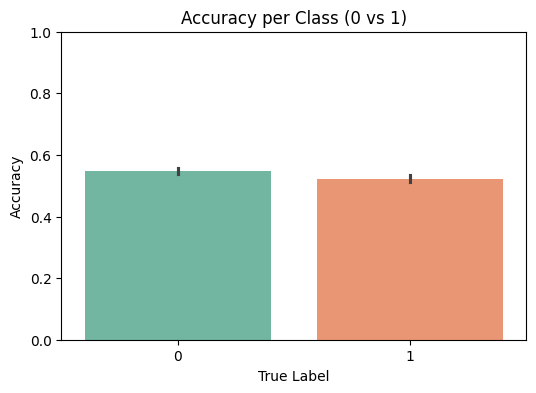

In [16]:
df_test["correct"] = (df_test["label_pred"] == df_test["label"])

plt.figure(figsize=(6,4))
sns.barplot(
    data=df_test,
    x="label",
    y="correct",
    estimator="mean",
    palette="Set2"
)
plt.title("Accuracy per Class (0 vs 1)")
plt.ylabel("Accuracy")
plt.xlabel("True Label")
plt.ylim(0,1)
plt.show()

### Accuracy per Class — Interpretation
- Class 0 accuracy ≈ Class 1 accuracy (≈ 0.54–0.55).
- The model is **not biased** toward any class — good balance.
- But both accuracies remain low → the classes are **hard to separate** using shallow features.

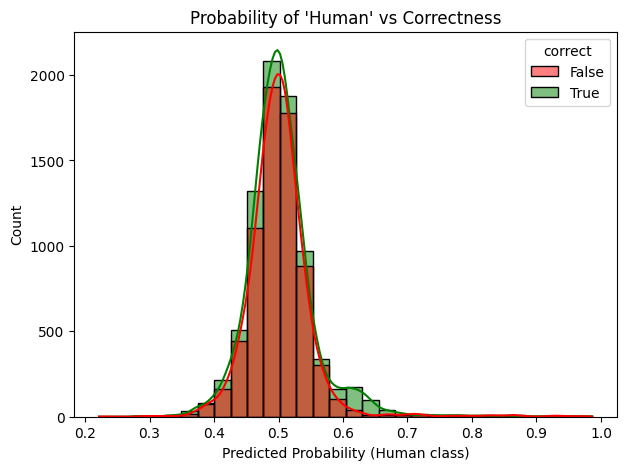

In [17]:
if "prob_human" in df_test.columns:

    plt.figure(figsize=(7,5))
    sns.histplot(
        data=df_test,
        x="prob_human",
        hue="correct",
        bins=30,
        kde=True,
        palette=["red", "green"],
        alpha=0.5
    )
    plt.title("Probability of 'Human' vs Correctness")
    plt.xlabel("Predicted Probability (Human class)")
    plt.show()

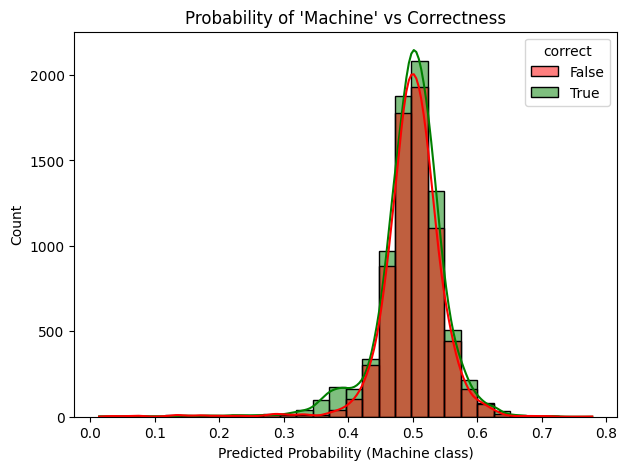

In [20]:
if "prob_machine" in df_test.columns:

    plt.figure(figsize=(7,5))
    sns.histplot(
        data=df_test,
        x="prob_machine",
        hue="correct",
        bins=30,
        kde=True,
        palette=["red", "green"],
        alpha=0.5
    )
    plt.title("Probability of 'Machine' vs Correctness")
    plt.xlabel("Predicted Probability (Machine class)")
    plt.show()

### Probability Histogram — Interpretation
- Correct and incorrect predictions have **overlapping probability ranges**.
- Most predictions cluster tightly around **0.48–0.55**.
- Model confidence is extremely low → reflects **weak separability**.
- No meaningful high-confidence cluster → indicates that the handcrafted features are helpful but not decisive.

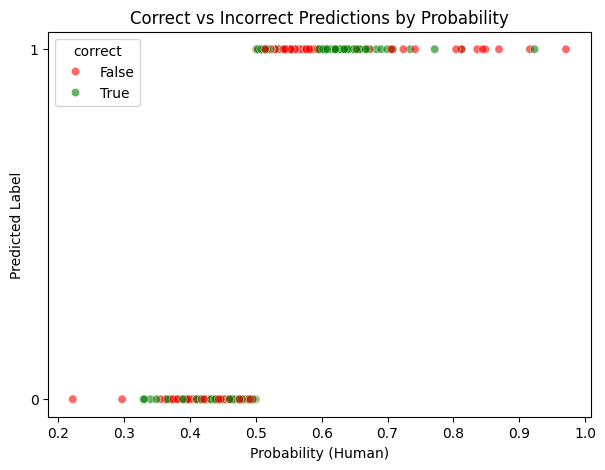

In [18]:
if "prob_human" in df_test.columns:

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=df_test.sample(min(2000, len(df_test))),  # avoid too many points
        x="prob_human",
        y="label_pred",
        hue="correct",
        palette=["red", "green"],
        alpha=0.6
    )
    plt.title("Correct vs Incorrect Predictions by Probability")
    plt.xlabel("Probability (Human)")
    plt.ylabel("Predicted Label")
    plt.yticks([0, 1])
    plt.show()

### Scatter Plot — Interpretation
- Both correct and incorrect points span the entire probability range (0.3–0.9).
- Predictions rarely reach very low or very high probability → low model certainty.
- Incorrect predictions do not cluster — errors are uniformly spread.
- Confirms: the classifier is **almost linear around the decision boundary**, with little margin.

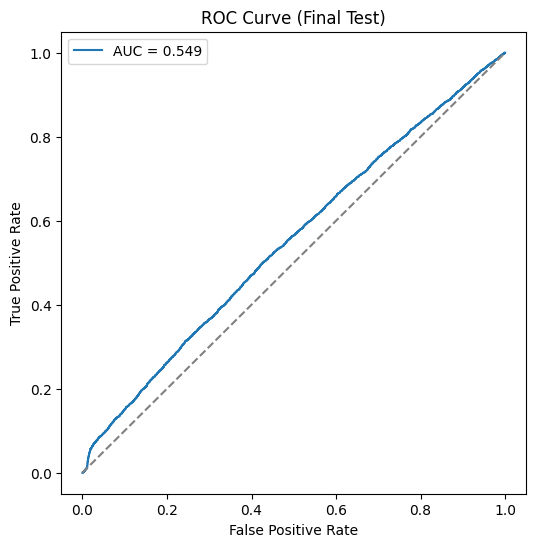

In [19]:
from sklearn.metrics import roc_curve, auc

if "prob_human" in df_test.columns:

    fpr, tpr, thresholds = roc_curve(df_test["label"], df_test["prob_human"])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Final Test)")
    plt.legend()
    plt.show()

### ROC Curve — Interpretation
- AUC ≈ **0.549** → only slightly above random (0.5).
- Confirms the model extracts **some** signal from handcrafted features,
  but the task remains intrinsically challenging.
- ROC shape follows the diagonal closely → **weakly predictive model**,
  consistent with earlier accuracy and probability diagnostics.